In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor 
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

In [2]:
X_train = pd.read_csv("data/challenge_train_features.csv", index_col=0)
y_train = pd.read_csv("data/challenge_train_revenue.csv", index_col=0)
X_test = pd.read_csv("data/challenge_test_features.csv", index_col=0)

In [3]:
def get_first_genre(X):
    """
    Extrait le premier genre de la liste des genres (séparés par des virgules)
    Example: 'Action, Adventure, Drama' -> 'Action'
    """
    X = X.copy()
    # Divise la chaîne par les virgules et prend le premier élément
    X['genre'] = X['genre'].str.split(',').str[0]
    # Gestion des valeurs manquantes
    X['genre'] = X['genre'].fillna('Unknown')
    return X[['genre']]

In [4]:
X_train["first_genre"] = get_first_genre(X_train)
get_first_genre(X_train)['genre'].value_counts()

genre
Drama              531
Comedy             407
Action             333
Adventure          122
Horror             117
Crime              100
Thriller            83
Documentary         52
Animation           50
Romance             44
Fantasy             39
Family              25
Science Fiction     25
Mystery             23
Music               14
War                 13
Western              8
History              7
Unknown              5
Foreign              2
Name: count, dtype: int64

In [ ]:
df = X_train.joint(y_train)

In [5]:
# Moyenne globale du revenu
moyenne_globale = df["revenue"].mean()

# Moyenne par catégorie
revenu_par_genre = df.groupby("first_genre")["revenue"].mean()

# Pourcentage d'écart par rapport à la moyenne globale
pourcentage_ecart = (revenu_par_genre / moyenne_globale - 1) * 100

# Résumé clair
resultat = pd.DataFrame({
    "revenu_moyen": revenu_par_genre,
    "écart_%_par_rapport_moyenne": pourcentage_ecart
})

print(resultat)


NameError: name 'df' is not defined

count    5.000000e+02
mean     3.526455e+07
std      4.172786e+07
min      2.196531e+06
25%      9.000000e+06
50%      2.000000e+07
75%      4.550000e+07
max      3.000000e+08
Name: budget, dtype: float64


<Figure size 640x480 with 0 Axes>

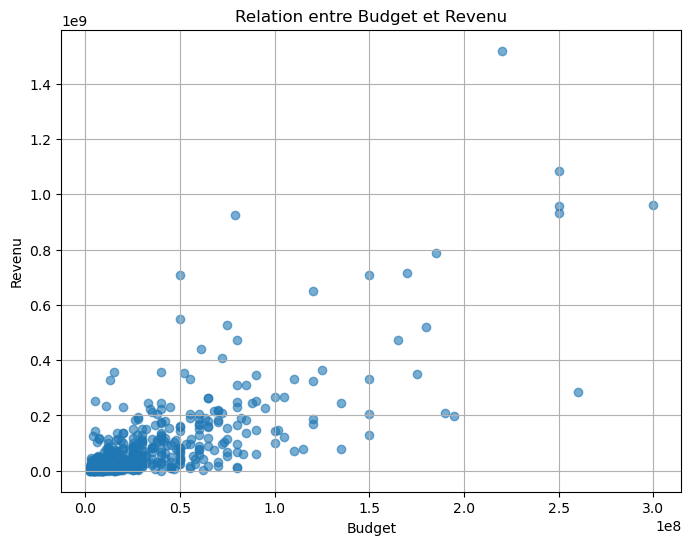

In [ ]:
# import matplotlib.pyplot as plt

# #garder les budget entre 0 et 100000
# df_temp = df[df['budget'] <= 2000000]

# plt.figure(figsize=(8,6))
# plt.scatter(df_temp['budget'], df_temp['revenue'], alpha=0.6)
# plt.xlabel('Budget')
# plt.ylabel('Revenu')
# plt.title('Relation entre Budget et Revenu')
# plt.grid(True)
# plt.show()

df_temp2 = df[df['budget'] > 2000000].copy()
df_temp2 = df_temp2[:500]


#passer le budget en millions
# df_temp2['budget'] = df_temp2['budget'] / 1_000_000
plt.clf() 
print(df_temp2["budget"].describe())
fig = plt.figure(figsize=(8,6))
plt.scatter(df_temp2['budget'], df_temp2['revenue'], alpha=0.6)
plt.xlabel('Budget')
plt.ylabel('Revenu')
plt.title('Relation entre Budget et Revenu')
plt.grid(True)
plt.show()
